# 📊 Análise Exploratória de Dados (EDA)
## Desafio Synapsee — Telco Customer Churn

**Objetivo:** Compreender o perfil dos clientes que cancelam o serviço (Churn), identificar problemas de qualidade nos dados e mapear as variáveis com maior poder preditivo.

---

## 1. Setup e Carregamento dos Dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# Caminhos absolutos baseados na raiz do repositório.
# Resolve qualquer diretório de trabalho (notebook, terminal, CI).
REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent
DATA_PATH = REPO_ROOT / 'data' / 'raw' / 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
FIGURES_DIR = REPO_ROOT / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f'Raiz do repositório: {REPO_ROOT}')
print(f'Arquivo de dados:    {DATA_PATH}')
print(f'Diretório de figuras: {FIGURES_DIR}')
print()

df_raw = pd.read_csv(DATA_PATH)
print(f'Shape: {df_raw.shape}')
df_raw.head()

Raiz do repositório: C:\Users\berna\.antigravity\projects\ds-synapsee-challenge\ds-synapsee-challenge
Arquivo de dados:    C:\Users\berna\.antigravity\projects\ds-synapsee-challenge\ds-synapsee-challenge\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv
Diretório de figuras: C:\Users\berna\.antigravity\projects\ds-synapsee-challenge\ds-synapsee-challenge\reports\figures

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Visão Geral e Tipos de Dados

In [2]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [3]:
df_raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Contagem de valores únicos por coluna
print('Valores únicos por coluna:')
print(df_raw.nunique().to_string())

Valores únicos por coluna:
customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2


## 3. Detecção de Nulos Ocultos

**Hipótese mapeada no PLANO:** A coluna `TotalCharges` pode conter espaços em branco (strings vazias) que impedem a conversão para numérico, mascarando valores nulos.

In [5]:
# 3.1 - Nulos explícitos (NaN) no DataFrame original
print('=== Nulos explícitos (isnull) ===')
nulos_explicitos = df_raw.isnull().sum()
print(nulos_explicitos[nulos_explicitos > 0] if nulos_explicitos.sum() > 0 else 'Nenhum NaN explícito encontrado.')
print()

=== Nulos explícitos (isnull) ===
Nenhum NaN explícito encontrado.



In [6]:
# 3.2 - Investigação: TotalCharges é string quando deveria ser numérica
# pandas 3.x usa dtype 'str' nativo ao invés de 'object'
print(f'Tipo de TotalCharges: {df_raw["TotalCharges"].dtype}')
print()

# Detectar linhas com espaço em branco
mascara_espacos = df_raw['TotalCharges'].str.strip() == ''
n_espacos = mascara_espacos.sum()
print(f'Linhas com espaço em branco em TotalCharges: {n_espacos}')
print()

if n_espacos > 0:
    print('Registros afetados:')
    display(df_raw[mascara_espacos][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']])

Tipo de TotalCharges: str

Linhas com espaço em branco em TotalCharges: 11

Registros afetados:


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [7]:
# 3.3 - Diagnóstico: Esses clientes têm tenure == 0 (recém-chegados)?
if n_espacos > 0:
    print('Distribuição de tenure nos registros com TotalCharges vazio:')
    print(df_raw.loc[mascara_espacos, 'tenure'].value_counts())
    print()
    print('>>> Conclusão: Clientes com tenure=0 não tiveram cobrança acumulada,\n'
          '    logo TotalCharges vazio é esperado (nulo semântico, não erro de cadastro).')

Distribuição de tenure nos registros com TotalCharges vazio:
tenure
0    11
Name: count, dtype: int64

>>> Conclusão: Clientes com tenure=0 não tiveram cobrança acumulada,
    logo TotalCharges vazio é esperado (nulo semântico, não erro de cadastro).


## 4. Análise de Desbalanceamento da Target (`Churn`)

In [8]:
# 4.1 - Distribuição absoluta e percentual
churn_counts = df_raw['Churn'].value_counts()
churn_pct = df_raw['Churn'].value_counts(normalize=True) * 100

print('Distribuição da Target (Churn):')
print(pd.DataFrame({'Contagem': churn_counts, 'Percentual (%)': churn_pct.round(2)}))
print(f'\nRazão de desbalanceamento (No/Yes): {churn_counts["No"] / churn_counts["Yes"]:.2f}:1')

Distribuição da Target (Churn):
       Contagem  Percentual (%)
Churn                          
No         5174           73.46
Yes        1869           26.54

Razão de desbalanceamento (No/Yes): 2.77:1


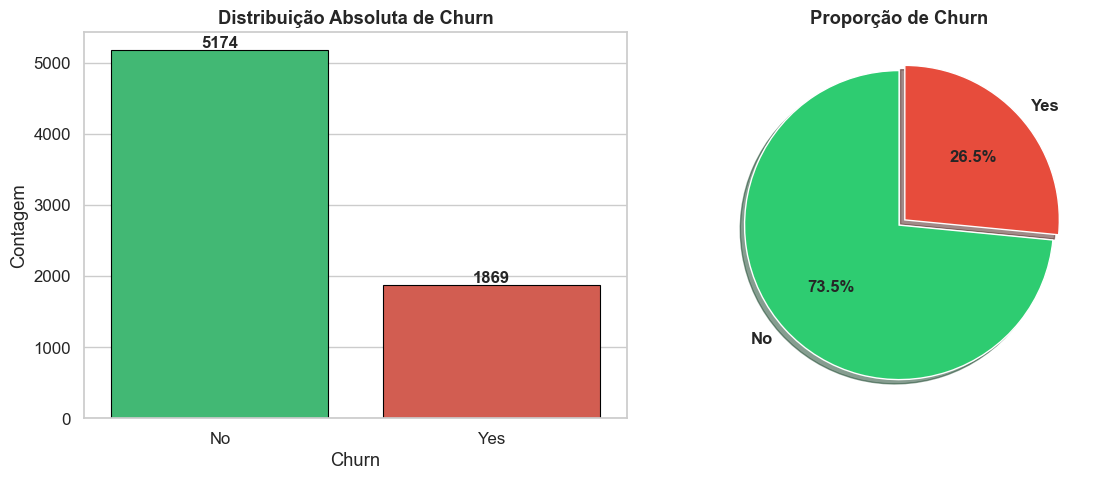

>>> Dataset desbalanceado: ~73% No vs ~27% Yes.


In [9]:
# 4.2 - Visualização do desbalanceamento
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#2ecc71', '#e74c3c']

# Gráfico de barras
sns.countplot(data=df_raw, x='Churn', ax=axes[0], palette=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Distribuição Absoluta de Churn', fontweight='bold')
axes[0].set_ylabel('Contagem')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontweight='bold', fontsize=12)

# Gráfico de pizza
axes[1].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0, 0.05),
            shadow=True, textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Proporção de Churn', fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_churn_distribuicao.png', bbox_inches='tight', dpi=150)
plt.show()
print('>>> Dataset desbalanceado: ~73% No vs ~27% Yes.')

## 5. Análise de Features Numéricas vs Churn

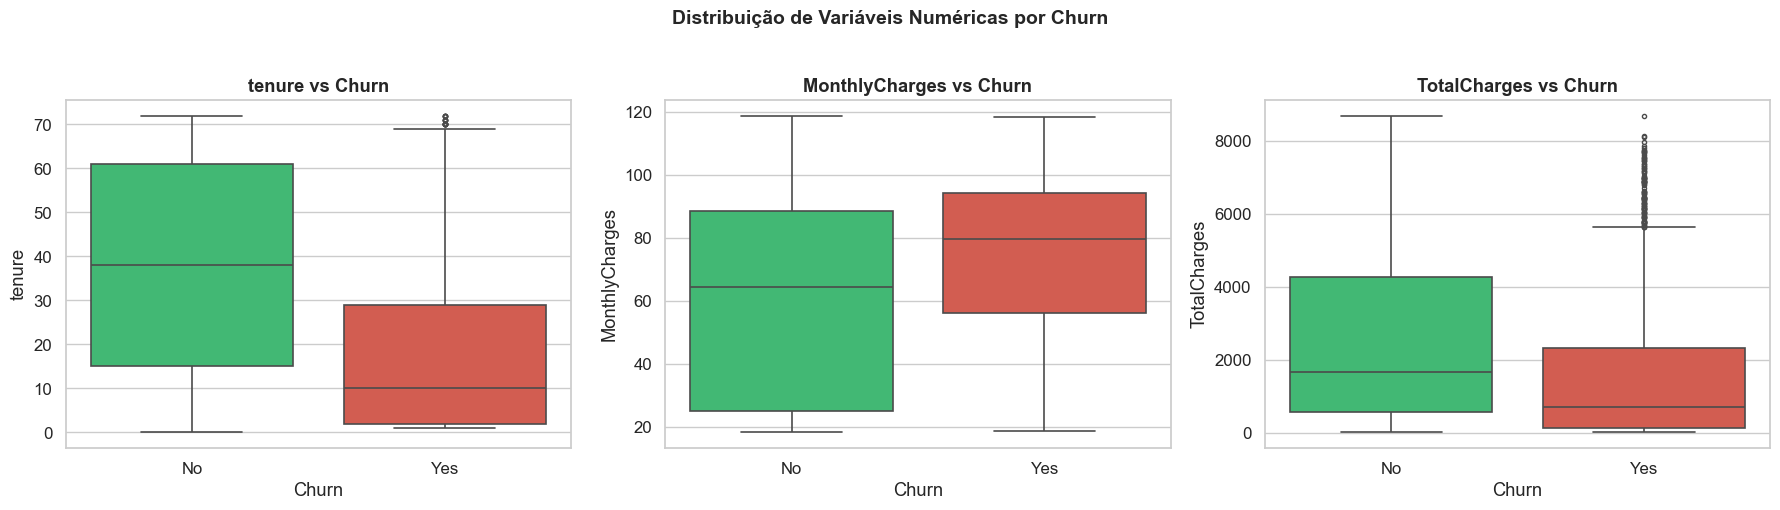

In [10]:
# Preparar TotalCharges como numérica para as análises
# Espaços em branco viram NaN temporariamente (tratamento definitivo na seção 11)
df_eda = df_raw.copy()
df_eda['TotalCharges'] = pd.to_numeric(df_eda['TotalCharges'], errors='coerce')

numericas = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(numericas):
    sns.boxplot(data=df_eda, x='Churn', y=col, ax=axes[i], palette=colors,
                linewidth=1.2, fliersize=3)
    axes[i].set_title(f'{col} vs Churn', fontweight='bold')

plt.suptitle('Distribuição de Variáveis Numéricas por Churn', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_numericas_vs_churn.png', bbox_inches='tight', dpi=150)
plt.show()

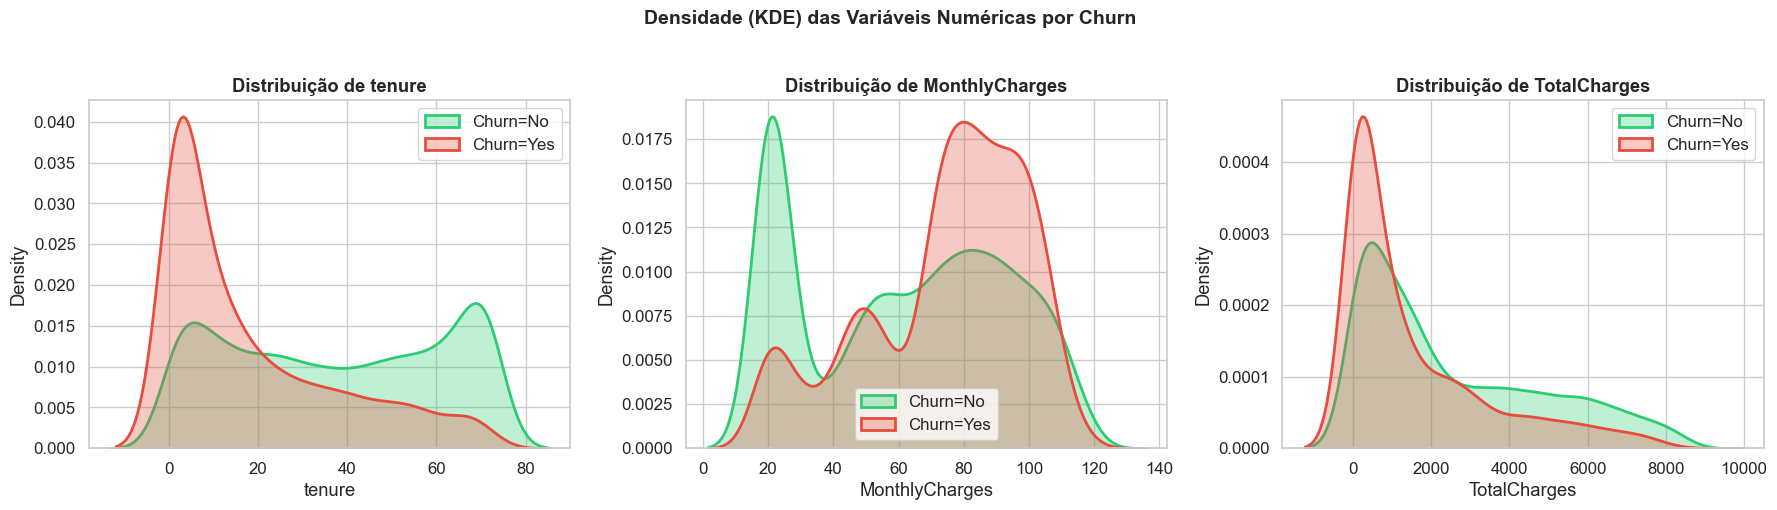

In [11]:
# 5.2 - Distribuições (KDE) lado a lado por Churn
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(numericas):
    for label, color in zip(['No', 'Yes'], colors):
        subset = df_eda[df_eda['Churn'] == label][col].dropna()
        sns.kdeplot(subset, ax=axes[i], label=f'Churn={label}', color=color, linewidth=2, fill=True, alpha=0.3)
    axes[i].set_title(f'Distribuição de {col}', fontweight='bold')
    axes[i].legend()

plt.suptitle('Densidade (KDE) das Variáveis Numéricas por Churn', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_kde_numericas.png', bbox_inches='tight', dpi=150)
plt.show()

In [12]:
# 5.3 - Estatísticas descritivas numéricas agrupadas por Churn
print('Estatísticas por classe de Churn:')
display(df_eda.groupby('Churn')[numericas].describe().T)

Estatísticas por classe de Churn:


Churn                          No          Yes
tenure         count  5174.000000  1869.000000
               mean     37.569965    17.979133
               std      24.113777    19.531123
               min       0.000000     1.000000
               25%      15.000000     2.000000
               50%      38.000000    10.000000
               75%      61.000000    29.000000
               max      72.000000    72.000000
MonthlyCharges count  5174.000000  1869.000000
               mean     61.265124    74.441332
               std      31.092648    24.666053
               min      18.250000    18.850000
               25%      25.100000    56.150000
               50%      64.425000    79.650000
               75%      88.400000    94.200000
               max     118.750000   118.350000
TotalCharges   count  5163.000000  1869.000000
               mean   2555.344141  1531.796094
               std    2329.456984  1890.822994
               min      18.800000    18.850000
               25%     577.825000   134.500000
               50%    1683.600000   703.550000
               75%    4264.125000  2331.300000
               max    8672.450000  8684.800000

## 6. Análise de Features Categóricas vs Churn

Vamos calcular a **taxa de churn** por categoria e identificar quais atributos apresentam maior diferença de comportamento entre clientes que cancelam e os que ficam.

In [13]:
# Identificar colunas categóricas relevantes (excluindo customerID e a target)
# pandas 3.x usa dtype 'str' nativo — usamos is_string_dtype para compatibilidade
categoricas = [col for col in df_eda.columns
               if pd.api.types.is_string_dtype(df_eda[col])
               and col not in ['customerID', 'Churn']]

print(f'Features categóricas identificadas ({len(categoricas)}):')
print(categoricas)

Features categóricas identificadas (15):
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


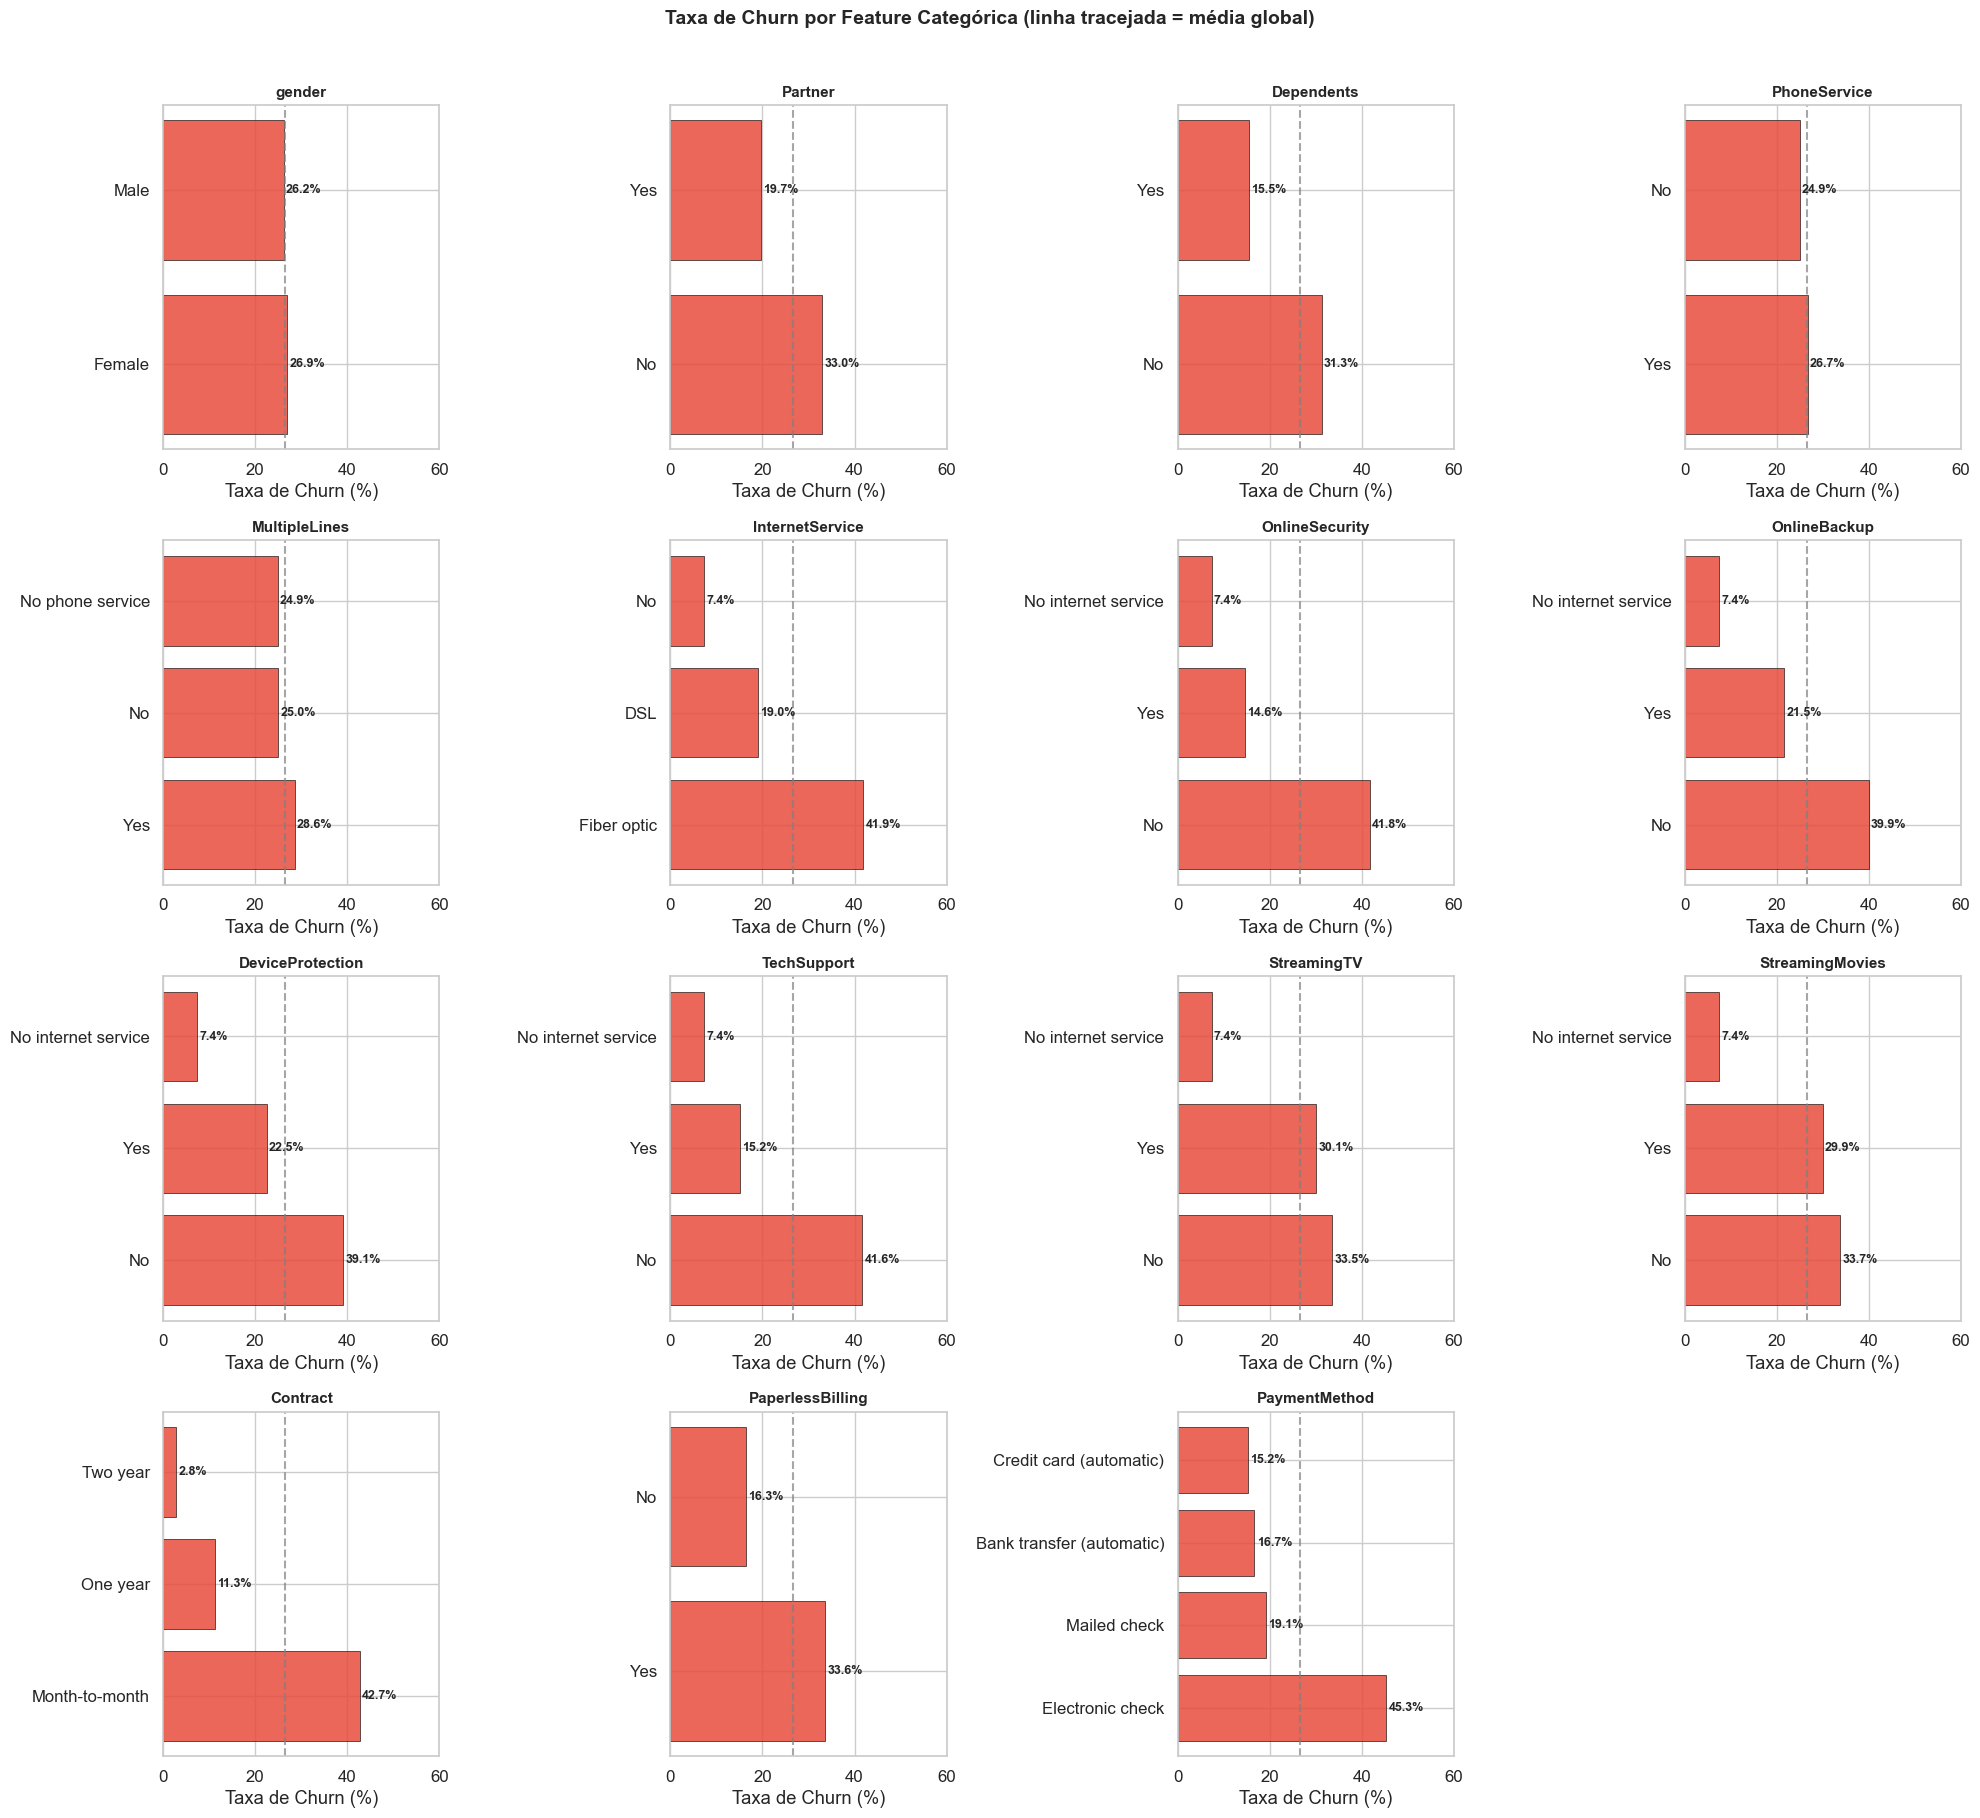

In [14]:
# 6.1 - Taxa de churn por categoria (visualização em grid)
n_cols_grid = 4
n_rows_grid = max(1, (len(categoricas) + n_cols_grid - 1) // n_cols_grid)

fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(20, n_rows_grid * 4.5))
axes = axes.flatten()

for i, col in enumerate(categoricas):
    # Calcular taxa de churn por categoria
    churn_rate = df_eda.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
    churn_rate = churn_rate.sort_values(ascending=False)

    bars = axes[i].barh(churn_rate.index, churn_rate.values, color='#e74c3c', edgecolor='black', linewidth=0.5, alpha=0.85)
    axes[i].set_title(f'{col}', fontweight='bold', fontsize=11)
    axes[i].set_xlabel('Taxa de Churn (%)')
    axes[i].set_xlim(0, 60)
    axes[i].axvline(x=churn_pct['Yes'], color='gray', linestyle='--', alpha=0.7,
                    label=f'Média global ({churn_pct["Yes"]:.1f}%)')

    # Rótulos nas barras
    for bar, val in zip(bars, churn_rate.values):
        axes[i].text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%',
                     va='center', fontsize=9, fontweight='bold')

# Esconder subplots extras
for j in range(len(categoricas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Taxa de Churn por Feature Categórica (linha tracejada = média global)',
             fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_categoricas_vs_churn.png', bbox_inches='tight', dpi=150)
plt.show()

## 7. Ranking de Relevância: Features com Maior Peso no Churn

Ranking consolidado:
- **Numéricas:** Correlação ponto-bisserial com Churn (binary encoded)
- **Categóricas:** Cramér's V para medir a associação com Churn

In [15]:
from scipy.stats import pointbiserialr, chi2_contingency

# Encode Churn como binário para cálculos
churn_binary = (df_eda['Churn'] == 'Yes').astype(int)

# --- Correlação ponto-bisserial para numéricas ---
print('=== Correlação Ponto-Bisserial (Numéricas vs Churn) ===')
resultados_num = []
for col in numericas:
    valid = df_eda[col].dropna()
    corr, pval = pointbiserialr(churn_binary[valid.index], valid)
    resultados_num.append({'Feature': col, 'Correlação': round(corr, 4), 'p-valor': f'{pval:.2e}'})

df_corr_num = pd.DataFrame(resultados_num).sort_values('Correlação', key=abs, ascending=False)
display(df_corr_num)
print()

=== Correlação Ponto-Bisserial (Numéricas vs Churn) ===


,Feature,Correlação,p-valor
0,tenure,-0.3522,8.00e-205
2,TotalCharges,-0.1995,4.88e-64
1,MonthlyCharges,0.1934,2.71e-60


In [16]:
# --- Cramér's V para categóricas ---
def cramers_v(x, y):
    """Calcula Cramér's V para medir associação entre duas variáveis categóricas.

    Parâmetros:
        x (pd.Series): Variável categórica independente.
        y (pd.Series): Variável categórica dependente (target).

    Retorna:
        float: Valor de Cramér's V entre 0 (sem associação) e 1 (associação perfeita).

    Lógica: Usa qui-quadrado de Pearson normalizado pelo tamanho da amostra
    e a menor dimensão da tabela de contingência, tornando o resultado
    comparável entre variáveis com número diferente de categorias.
    """
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    min_dim = min(confusion_matrix.shape) - 1
    return np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0

print("=== Cramér's V (Categóricas vs Churn) ===")
resultados_cat = []
for col in categoricas:
    v = cramers_v(df_eda[col], df_eda['Churn'])
    resultados_cat.append({'Feature': col, "Cramér's V": round(v, 4)})

df_cramer = pd.DataFrame(resultados_cat).sort_values("Cramér's V", ascending=False)
display(df_cramer)

=== Cramér's V (Categóricas vs Churn) ===


,Feature,Cramér's V
12,Contract,0.4101
6,OnlineSecurity,0.3474
9,TechSupport,0.3429
5,InternetService,0.3225
14,PaymentMethod,0.3034
7,OnlineBackup,0.2923
8,DeviceProtection,0.2816
11,StreamingMovies,0.2310
10,StreamingTV,0.2305
13,PaperlessBilling,0.1915


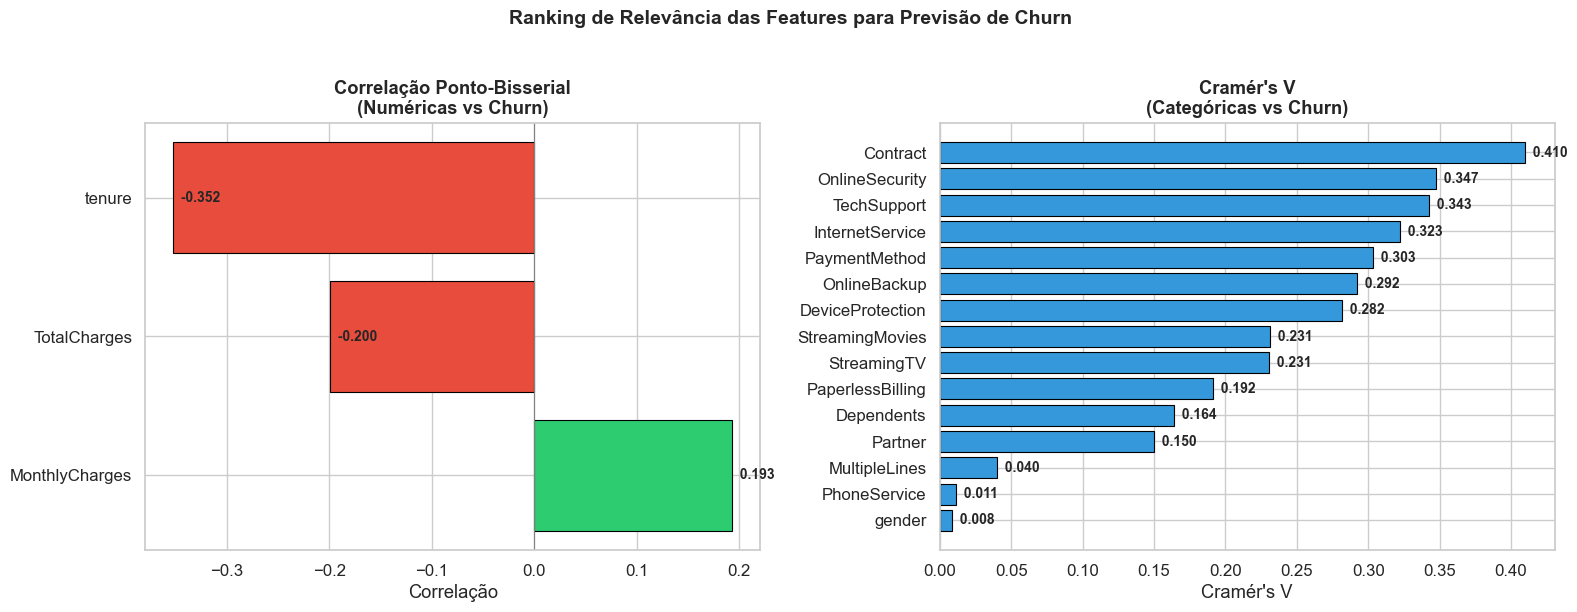

In [17]:
# 7.1 - Ranking visual consolidado
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Numéricas
df_corr_plot = df_corr_num.sort_values('Correlação', key=abs, ascending=True)
bar_colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in df_corr_plot['Correlação']]
axes[0].barh(df_corr_plot['Feature'], df_corr_plot['Correlação'], color=bar_colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Correlação Ponto-Bisserial\n(Numéricas vs Churn)', fontweight='bold')
axes[0].set_xlabel('Correlação')
axes[0].axvline(x=0, color='gray', linewidth=0.8)
for idx, row in df_corr_plot.iterrows():
    axes[0].text(row['Correlação'], row['Feature'], f"  {row['Correlação']:.3f}", va='center', fontweight='bold', fontsize=10)

# Categóricas
df_cramer_plot = df_cramer.sort_values("Cramér's V", ascending=True)
axes[1].barh(df_cramer_plot['Feature'], df_cramer_plot["Cramér's V"], color='#3498db', edgecolor='black', linewidth=0.8)
axes[1].set_title("Cramér's V\n(Categóricas vs Churn)", fontweight='bold')
axes[1].set_xlabel("Cramér's V")
for idx, row in df_cramer_plot.iterrows():
    axes[1].text(row["Cramér's V"], row['Feature'], f"  {row['Cramér' + chr(39) + 's V']:.3f}", va='center', fontweight='bold', fontsize=10)

plt.suptitle('Ranking de Relevância das Features para Previsão de Churn', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_ranking_features.png', bbox_inches='tight', dpi=150)
plt.show()

## 8. Correlação entre Variáveis Numéricas (Heatmap)

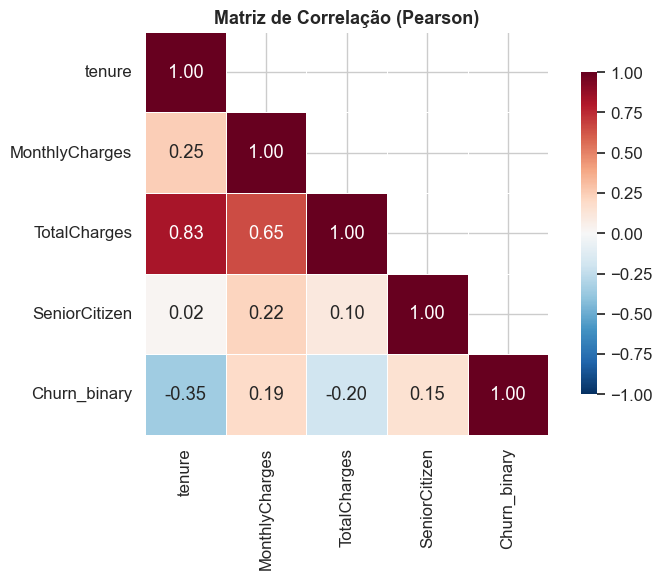

In [18]:
# Incluir SeniorCitizen (já é numérica 0/1) e Churn codificado
df_corr_matrix = df_eda[numericas + ['SeniorCitizen']].copy()
df_corr_matrix['Churn_binary'] = churn_binary

fig, ax = plt.subplots(figsize=(8, 6))
corr_matrix = df_corr_matrix.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            square=True, cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de Correlação (Pearson)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_heatmap_correlacao.png', bbox_inches='tight', dpi=150)
plt.show()

## 9. Varredura Sistêmica de Qualidade de Dados

Checagem abrangente em **todas** as colunas do dataset, procurando por:
- Espaços em branco, strings vazias, marcadores de nulo disfarçados (`?`, `NA`, `N/A`, `null`, `-`)
- Outliers ilógicos nas variáveis numéricas (`tenure` negativo, cobranças negativas, etc.)

In [19]:
# 9.1 - Varredura de anomalias em colunas de texto
# Procura por valores suspeitos que podem mascarar nulos ou erros de cadastro
MARCADORES_NULO = ['', ' ', '?', 'NA', 'N/A', 'null', 'NULL', 'None', 'none', '-', '--', 'nan', 'NaN']

colunas_texto = [col for col in df_raw.columns if pd.api.types.is_string_dtype(df_raw[col])]

print('=== Varredura de Anomalias em Colunas de Texto ===')
print(f'Colunas verificadas: {len(colunas_texto)}')
print()

anomalias_encontradas = {}
for col in colunas_texto:
    resultados_coluna = {}
    for marcador in MARCADORES_NULO:
        # Comparação exata após strip para capturar espaços em branco
        contagem = (df_raw[col].str.strip() == marcador).sum()
        if contagem > 0:
            label = repr(marcador) if marcador.strip() == '' else marcador
            resultados_coluna[label] = contagem
    if resultados_coluna:
        anomalias_encontradas[col] = resultados_coluna

if anomalias_encontradas:
    print('⚠️  Anomalias detectadas:')
    for col, detalhes in anomalias_encontradas.items():
        print(f'  📌 {col}:')
        for marcador, contagem in detalhes.items():
            print(f'      {marcador}: {contagem} ocorrências')
else:
    print('✅ Nenhuma anomalia de texto encontrada além das já mapeadas (TotalCharges).')

print()

=== Varredura de Anomalias em Colunas de Texto ===
Colunas verificadas: 18

⚠️  Anomalias detectadas:
  📌 TotalCharges:
      '': 11 ocorrências



In [20]:
# 9.2 - Validação de integridade das variáveis numéricas
# Verifica se existem valores ilógicos (negativos, extremos absurdos)
print('=== Validação de Integridade Numérica ===')
print()

variaveis_numericas_completas = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
stats = df_eda[variaveis_numericas_completas].describe()
display(stats)
print()

# Checagem de valores negativos (ilógicos para estas variáveis de negócio)
print('--- Checagem de Valores Negativos ---')
for col in variaveis_numericas_completas:
    negativos = (df_eda[col].dropna() < 0).sum()
    print(f'  {col}: {negativos} valores negativos {"⚠️" if negativos > 0 else "✅"}')
print()

# Checagem de valores fora do domínio esperado
print('--- Checagem de Domínio Lógico ---')

# SeniorCitizen deve ser 0 ou 1
senior_invalidos = (~df_eda['SeniorCitizen'].isin([0, 1])).sum()
print(f'  SeniorCitizen fora de {{0,1}}: {senior_invalidos} {"⚠️" if senior_invalidos > 0 else "✅"}')

# tenure >= 0, verificar máximo razoável
tenure_max = df_eda['tenure'].max()
print(f'  tenure máximo: {tenure_max} meses ({tenure_max/12:.1f} anos) {"⚠️ (>10 anos?)" if tenure_max > 120 else "✅"}')

# MonthlyCharges > 0 para todos
monthly_zero = (df_eda['MonthlyCharges'] == 0).sum()
print(f'  MonthlyCharges == 0: {monthly_zero} {"⚠️" if monthly_zero > 0 else "✅"}')

# Duplicatas de ID
duplicatas_id = df_raw['customerID'].duplicated().sum()
print(f'  Duplicatas de customerID: {duplicatas_id} {"⚠️" if duplicatas_id > 0 else "✅"}')

print()
print('>>> Conclusão: Dataset sem anomalias numéricas. Valores dentro dos limites lógicos esperados.')

=== Validação de Integridade Numérica ===



,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000



--- Checagem de Valores Negativos ---
  SeniorCitizen: 0 valores negativos ✅
  tenure: 0 valores negativos ✅
  MonthlyCharges: 0 valores negativos ✅
  TotalCharges: 0 valores negativos ✅

--- Checagem de Domínio Lógico ---
  SeniorCitizen fora de {0,1}: 0 ✅
  tenure máximo: 72 meses (6.0 anos) ✅
  MonthlyCharges == 0: 0 ✅
  Duplicatas de customerID: 0 ✅

>>> Conclusão: Dataset sem anomalias numéricas. Valores dentro dos limites lógicos esperados.


---
## 10. Transformações Aprovadas (Ponto de Controle Validado)

Decisões aprovadas pelo usuário após a EDA:
1. **Imputar TotalCharges** com `0` nos 11 registros com `tenure=0`
2. **Criar `TicketMedio`** = `TotalCharges / tenure` (para `tenure > 0`; `0` quando `tenure == 0`)
3. **Dropar `TotalCharges`** original para mitigar multicolinearidade com `tenure`
4. **Balanceamento por `class_weight='balanced'`** será adotado na etapa de modelagem

In [21]:
# 10.1 - Imputar TotalCharges com 0 nos registros com espaço em branco (tenure=0)
# Justificativa: São clientes recém-chegados sem cobrança acumulada (nulo semântico)
df_eda['TotalCharges'] = pd.to_numeric(df_eda['TotalCharges'], errors='coerce').fillna(0)

print(f'NaN restantes em TotalCharges: {df_eda["TotalCharges"].isnull().sum()}')
print(f'Registros com TotalCharges == 0: {(df_eda["TotalCharges"] == 0).sum()}')
print(f'Tenure desses registros: {df_eda.loc[df_eda["TotalCharges"] == 0, "tenure"].unique()}')

NaN restantes em TotalCharges: 0


Registros com TotalCharges == 0: 11
Tenure desses registros: [0]


In [22]:
# 10.2 - Criar feature TicketMedio: gasto médio mensal real do cliente
# Fórmula: TotalCharges / tenure (quando tenure > 0), senão 0
# Objetivo: Substituir TotalCharges por uma métrica sem multicolinearidade com tenure
# e com significado direto de negócio (valor médio gasto por mês de permanência)
df_eda['TicketMedio'] = np.where(
    df_eda['tenure'] > 0,
    df_eda['TotalCharges'] / df_eda['tenure'],
    0  # Clientes com tenure=0 não têm histórico de gasto
)

print('Estatísticas de TicketMedio:')
print(df_eda['TicketMedio'].describe())
print()
print('TicketMedio médio por classe de Churn:')
print(df_eda.groupby('Churn')['TicketMedio'].mean())

Estatísticas de TicketMedio:
count    7043.000000
mean       64.698218
std        30.270670
min         0.000000
25%        35.649000
50%        70.300000
75%        90.174158
max       121.400000
Name: TicketMedio, dtype: float64

TicketMedio médio por classe de Churn:
Churn
No     61.181674
Yes    74.433154
Name: TicketMedio, dtype: float64


In [23]:
# 10.3 - Dropar TotalCharges original (mitigar multicolinearidade com tenure)
df_eda = df_eda.drop(columns=['TotalCharges'])

print(f'Shape final de df_eda: {df_eda.shape}')
print(f'Colunas: {list(df_eda.columns)}')

Shape final de df_eda: (7043, 21)
Colunas: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'Churn', 'TicketMedio']


## 11. Resumo Executivo da EDA

### Achados Principais:

1. **Nulos Ocultos:** `TotalCharges` continha 11 espaços em branco (clientes com `tenure=0`). Imputados com `0` (decisão aprovada).

2. **Qualidade Geral:** Varredura sistêmica confirmou zero anomalias adicionais. Sem `?`, `NA`, strings corrompidas. Sem valores negativos, sem duplicatas de IDs.

3. **Desbalanceamento:** ~26.5% Churn=Yes (ratio 2.77:1). Estratégia: `class_weight='balanced'` na modelagem.

4. **Features Numéricas com Forte Sinal:**
   - `tenure` (correlação -0.35): Clientes antigos cancelam muito menos
   - `MonthlyCharges` (+0.19): Cobranças altas associadas a maior churn

5. **Features Categóricas com Maior Peso (Cramér's V):**
   - `Contract` (Month-to-month tem churn altíssimo)
   - `OnlineSecurity` / `TechSupport` (ausência eleva churn)
   - `InternetService` (Fiber optic tem taxa elevada)
   - `PaymentMethod` (Electronic check concentra mais churn)

6. **Feature Engineering:** `TicketMedio` criada (TotalCharges/tenure). `TotalCharges` original dropada (multicolinearidade com tenure ~0.83).

### Próximos Passos (Etapa 2 — Pipeline de Features):
- Encoding de variáveis categóricas
- Escalonamento de numéricas
- Seleção de features